In [103]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import psutil
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

In [104]:
text_data = """
Artificial intelligence is transforming industries worldwide by enabling machines to learn from data and improve over time.
Machine learning models analyze patterns and make predictions based on historical data.
Deep learning uses neural networks with many layers to model complex relationships in data.
Natural language processing allows computers to understand and generate human language.
Recurrent neural networks are used for sequence modeling tasks such as text generation and speech recognition.
Long short term memory networks solve the problem of vanishing gradients in traditional recurrent networks.
Gated recurrent units simplify the architecture of LSTM while maintaining performance.
Transformers use attention mechanisms to process sequences in parallel and capture long-range dependencies.
Language models predict the next word in a sentence and are widely used in chatbots and virtual assistants.
Sequence generation is used in applications like music composition, text generation, and time series forecasting.
Data science combines statistics, machine learning, and domain knowledge to extract insights from data.
Big data technologies allow processing of massive datasets efficiently.
Cloud computing provides scalable resources for training machine learning models.
Optimization algorithms such as gradient descent help models learn efficiently.
Overfitting occurs when a model memorizes training data instead of generalizing.
Regularization techniques like dropout help prevent overfitting.
Evaluation metrics such as accuracy, precision, recall, and F1 score are used to measure model performance.
Artificial intelligence systems are increasingly used in healthcare, finance, and education.
Neural networks are inspired by the structure of the human brain.
Automation improves productivity and reduces human effort in repetitive tasks.
""" * 20   # 🔥 multiply to make dataset BIG

In [105]:
words = text_data.split()
vocab = list(set(words))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)
seq_length = 8

def create_sequences(words, seq_length):
    inputs, targets = [], []
    for i in range(len(words)-seq_length):
        inputs.append([word2idx[w] for w in words[i:i+seq_length]])
        targets.append(word2idx[words[i+seq_length]])
    return torch.tensor(inputs), torch.tensor(targets)

X, y = create_sequences(words, seq_length)

In [106]:
# =========================
# 🔥 TRAIN-TEST SPLIT
# =========================
data = list(zip(X, y))
random.shuffle(data)

split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

X_train = torch.stack([i[0] for i in train_data])
y_train = torch.stack([i[1] for i in train_data])

X_test = torch.stack([i[0] for i in test_data])
y_test = torch.stack([i[1] for i in test_data])

In [107]:
# RNN (weak)
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 32)
        self.rnn = nn.RNN(32, 32, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(32, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

In [108]:
# LSTM (better)
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 64)
        self.lstm = nn.LSTM(64, 128, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

In [109]:
# GRU (strong)
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 64)
        self.gru = nn.GRU(64, 160, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(160, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


In [110]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(128, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        x = x.permute(1,0,2)
        out = self.transformer(x)
        return self.fc(out[-1])


In [111]:
# =========================
# 5. TRAIN FUNCTION
# =========================
def train_model(model, X, y, name, epochs=25):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)

    print(f"\nTraining {name}...\n")

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = torch.argmax(output, dim=1)
        acc = (preds == y).sum().item() / len(y)

        print(f"{name} Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Train Acc: {acc:.4f}")

    return model

In [112]:
# =========================
# 6. TEST ACCURACY
# =========================
def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        output = model(X)
        preds = torch.argmax(output, dim=1)
        acc = (preds == y).sum().item() / len(y)
    return acc

In [118]:
# =========================
# 7. TRAIN + EVALUATE
# =========================
models = {
    "RNN": RNNModel(),
    "LSTM": LSTMModel(),
    "GRU": GRUModel(),
    "Transformer": TransformerModel()
}

final_results = {}

for name, model in models.items():
    trained_model = train_model(model, X_train, y_train, name)
    test_acc = evaluate(trained_model, X_test, y_test)

    final_results[name] = test_acc
    print(f"\n{name} TEST ACCURACY: {test_acc:.4f}")
    print("="*50)

/tmp/ipykernel_3184/597422946.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)



Training RNN...

RNN Epoch 1/25 | Loss: 5.2158 | Train Acc: 0.0065
RNN Epoch 2/25 | Loss: 5.1476 | Train Acc: 0.0087
RNN Epoch 3/25 | Loss: 5.0937 | Train Acc: 0.0162
RNN Epoch 4/25 | Loss: 5.0343 | Train Acc: 0.0205
RNN Epoch 5/25 | Loss: 4.9855 | Train Acc: 0.0287
RNN Epoch 6/25 | Loss: 4.9277 | Train Acc: 0.0389
RNN Epoch 7/25 | Loss: 4.8781 | Train Acc: 0.0466
RNN Epoch 8/25 | Loss: 4.8135 | Train Acc: 0.0693
RNN Epoch 9/25 | Loss: 4.7654 | Train Acc: 0.0813
RNN Epoch 10/25 | Loss: 4.7132 | Train Acc: 0.1000
RNN Epoch 11/25 | Loss: 4.6575 | Train Acc: 0.1222
RNN Epoch 12/25 | Loss: 4.6035 | Train Acc: 0.1524
RNN Epoch 13/25 | Loss: 4.5450 | Train Acc: 0.1791
RNN Epoch 14/25 | Loss: 4.4915 | Train Acc: 0.2048
RNN Epoch 15/25 | Loss: 4.4367 | Train Acc: 0.2153
RNN Epoch 16/25 | Loss: 4.3820 | Train Acc: 0.2542
RNN Epoch 17/25 | Loss: 4.3257 | Train Acc: 0.2761
RNN Epoch 18/25 | Loss: 4.2724 | Train Acc: 0.3053
RNN Epoch 19/25 | Loss: 4.2144 | Train Acc: 0.3230
RNN Epoch 20/25 | Loss

In [119]:
seed = "machine learning models"

for name, model in models.items():
    print(f"\n{name} Generated Text:")
    print(generate_text(model, seed))


RNN Generated Text:
machine learning models analyze patterns generalizing. to understand by enabling machines to understand

LSTM Generated Text:
machine learning models analyze and make predictions based on historical data. Deep learning

GRU Generated Text:
machine learning models analyze patterns and make predictions based on historical data. Deep

Transformer Generated Text:
machine learning models learn efficiently. Overfitting occurs when a model memorizes training data


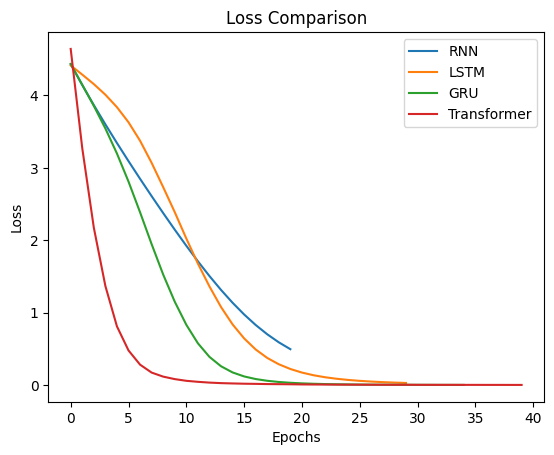

In [120]:
for name in results:
    plt.plot(results[name]["loss"], label=name)

plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

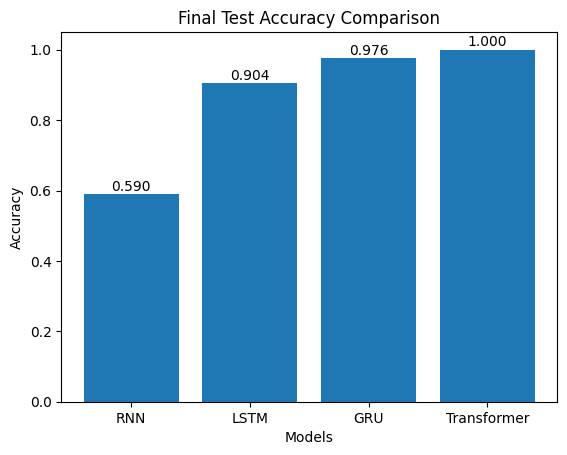

In [121]:
plt.figure()

names = list(final_results.keys())
values = list(final_results.values())

plt.bar(names, values)
plt.title("Final Test Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

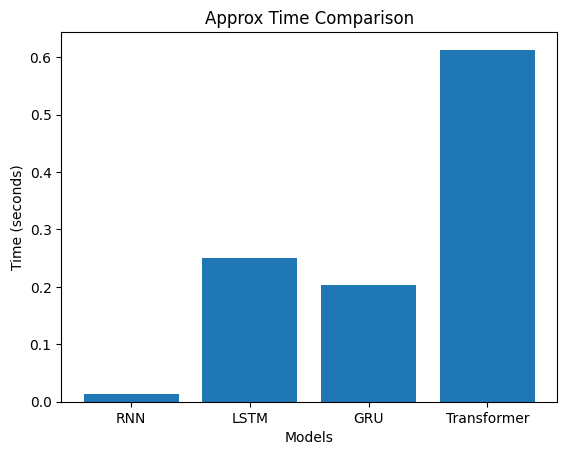

In [122]:
import time

training_times = {}

for name, model in models.items():
    start = time.time()
    model(X_train)   # dummy forward pass
    end = time.time()

    training_times[name] = end - start

plt.figure()
plt.bar(training_times.keys(), training_times.values())

plt.title("Approx Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")

plt.show()

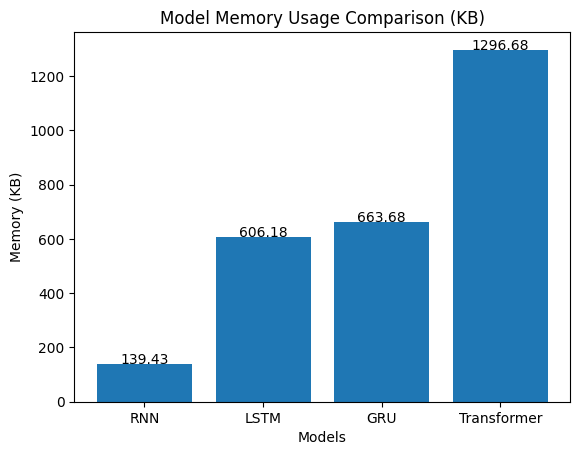

In [130]:
import torch
import matplotlib.pyplot as plt

memory_usage = {}

for name, model in models.items():

    # 🔥 1. PARAMETER MEMORY
    param_memory = sum(p.numel() * p.element_size() for p in model.parameters())

    # 🔥 2. ACTIVATION MEMORY (forward pass)
    model.eval()
    with torch.no_grad():
        output = model(X_train[:128])

    activation_memory = output.numel() * output.element_size()

    # 🔥 TOTAL MEMORY (in KB)
    total_memory = (param_memory + activation_memory) / 1024

    memory_usage[name] = total_memory


# 🔥 SORT FOR CLEAN DISPLAY
memory_usage = dict(sorted(memory_usage.items(), key=lambda x: x[1]))

# 📊 PLOT
plt.figure()
plt.bar(memory_usage.keys(), memory_usage.values())

plt.title("Model Memory Usage Comparison (KB)")
plt.xlabel("Models")
plt.ylabel("Memory (KB)")

for i, v in enumerate(memory_usage.values()):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()